In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Part 1 — Exploratory Data Analysis
This part focuses on understanding the dataset before building charts. The goal is to inspect the structure, identify missing values, and prepare the data for deeper analysis.

## 1.1 Dataset Overview
The Titanic dataset records the survival outcomes of passengers aboard the RMS Titanic. It contains demographic, socioeconomic, and ticket-related information that can help explain survival patterns.

## Q1 — Initial Inspection

In [3]:
# (a) Display first 8 rows and last 5 rows
display(df.head(8))
display(df.tail(5))

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [4]:
# (b) Shape, data types, numeric summary, categorical summary
print("Shape of dataset:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nNumeric summary:")
display(df.describe())

print("\nCategorical summary:")
display(df.describe(include='object'))

Shape of dataset: (891, 15)

Data types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Numeric summary:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Categorical summary:


,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [5]:
# (c) Missing values: count and percentage
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]
display(missing_summary.sort_values(by='Missing Percentage', ascending=False))

,Missing Count,Missing Percentage
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467


# (c) Missing values: count and percentage
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]
display(missing_summary.sort_values(by='Missing Percentage', ascending=False))

In [6]:
# (d) Overall survival rate and survival rate by pclass
overall_survival = df['survived'].mean()

survival_by_class = (
    df.groupby('pclass')['survived']
    .mean()
    .reset_index()
    .rename(columns={'survived': 'survival_rate'})
)

overall_df = pd.DataFrame({
    'Metric': ['Overall Survival Rate'],
    'Value': [overall_survival]
})

display(overall_df)
display(survival_by_class)

,Metric,Value
0,Overall Survival Rate,0.383838


,pclass,survival_rate
0,1,0.629630
1,2,0.472826
2,3,0.242363


### Interpretation

The overall survival rate is well below 50%, which shows that most passengers did not survive.  
When survival is broken down by passenger class, first-class passengers show the highest survival rate, while third-class passengers show the lowest. This suggests that socioeconomic status and ticket class played a strong role in survival chances.

## Q2 — Data Cleaning & Feature Engineering
The next step is to clean the dataset and create useful derived features for analysis.

In [7]:
# Make a working copy
df_clean = df.copy()

In [8]:
# (a) Impute missing age using group median by sex and pclass
df_clean['age'] = df_clean.groupby(['sex', 'pclass'])['age'].transform(
    lambda x: x.fillna(x.median())
)

df_clean['age'].isnull().sum()

np.int64(0)

### Age Imputation Justification

I used group-based median imputation by sex and pclass because age is likely related to both gender and ticket class.  
This is more meaningful than using one overall median for the entire dataset. A limitation is that imputation reduces natural variation and may hide unusual age patterns within groups.

In [9]:
# (b) Drop deck
df_clean = df_clean.drop(columns=['deck'])

### Why Drop `deck`?

The `deck` column contains too many missing values, so imputing it would introduce too much uncertainty.  
Since most of the entries are absent, dropping the column is more reliable than trying to guess missing deck information.

In [10]:
# (c) Fill missing embarked and embark_town with mode
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])
df_clean['embark_town'] = df_clean['embark_town'].fillna(df_clean['embark_town'].mode()[0])

df_clean[['embarked', 'embark_town']].isnull().sum()

embarked       0
embark_town    0
dtype: int64

In [11]:
# (d) Create family_size and travel_group
df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch'] + 1

def classify_group(x):
    if x == 1:
        return 'Solo'
    elif 2 <= x <= 4:
        return 'Small'
    else:
        return 'Large'

df_clean['travel_group'] = df_clean['family_size'].apply(classify_group)

df_clean['travel_group'].value_counts()

travel_group
Solo     537
Small    292
Large     62
Name: count, dtype: int64

In [12]:
# (e) Create age_group
bins = [0, 12, 17, 59, np.inf]
labels = ['Child', 'Teen', 'Adult', 'Senior']

df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df_clean[['age', 'age_group']].head()

,age,age_group
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult


In [13]:
# (f) Final null check for columns used forward
columns_used = [
    'survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
    'embarked', 'embark_town', 'family_size', 'travel_group', 'age_group'
]

final_null_check = df_clean[columns_used].isnull().sum()
display(final_null_check[final_null_check > 0])

Series([], dtype: int64)

### Cleaning Summary

After the cleaning process:
- missing `age` values were imputed,
- `deck` was removed,
- missing embarkation values were filled,
- new features `family_size`, `travel_group`, and `age_group` were created.

The columns used in the later analysis now have no missing values.

# Part 2 — Univariate Analysis & Distributions
This part studies one variable at a time to understand shape, spread, skewness, and category balance.

## Q3 — Age Distribution Deep-Dive

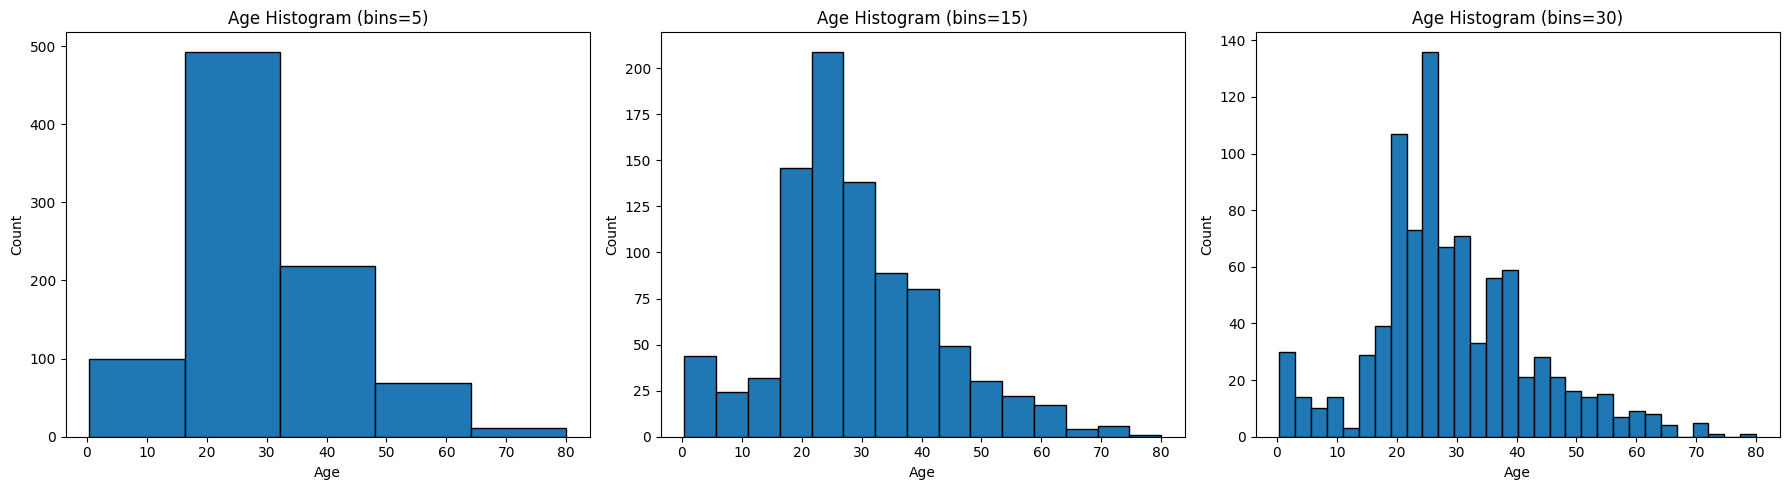

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, bins in zip(axes, [5, 15, 30]):
    ax.hist(df_clean['age'], bins=bins, edgecolor='black')
    ax.set_title(f'Age Histogram (bins={bins})')
    ax.set_xlabel('Age')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

### Bin Size Interpretation

- **5 bins:** This over-smooths the data because too much detail is lost and the age structure looks overly simplified.
- **15 bins:** This is approximately right because it shows the overall distribution clearly without making it too noisy.
- **30 bins:** This begins to under-smooth because the plot becomes too jagged and small fluctuations may appear more important than they are.

The best choice is **15 bins** because it balances clarity and detail.

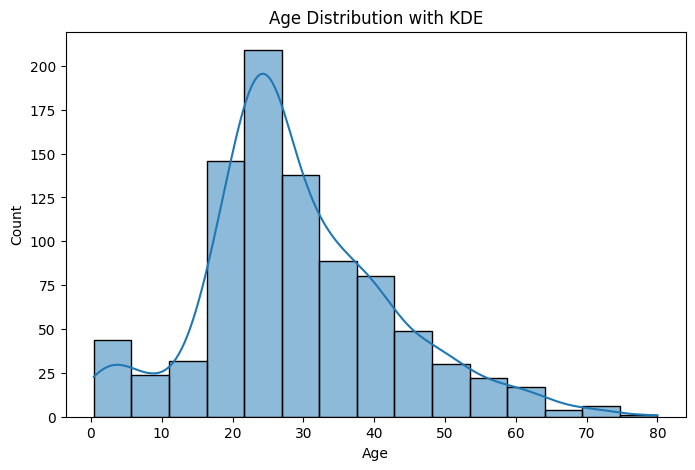

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_clean, x='age', bins=15, kde=True)
plt.title('Age Distribution with KDE')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### Interpretation

The age distribution is slightly right-skewed, with more passengers concentrated in younger and middle-adult age ranges.  
It is not perfectly symmetric and appears to have multiple small peaks, which may reflect different subgroups of passengers such as children, young adults, and older adults.  
The presence of many adults and fewer elderly passengers is consistent with the demographic makeup of ship travelers in that era.

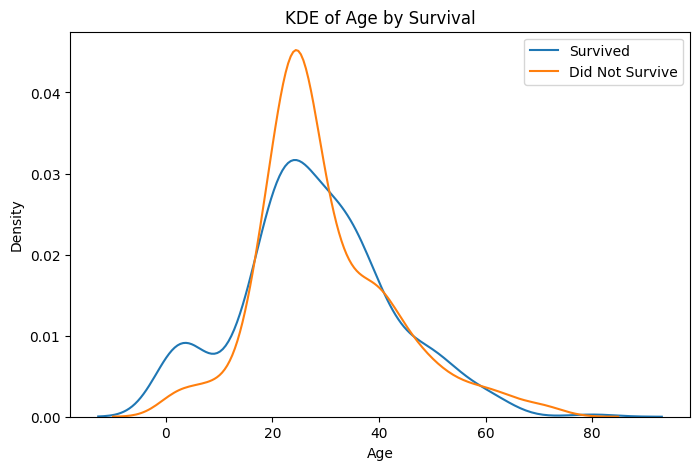

In [16]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_clean[df_clean['survived'] == 1], x='age', label='Survived', fill=False)
sns.kdeplot(data=df_clean[df_clean['survived'] == 0], x='age', label='Did Not Survive', fill=False)
plt.title('KDE of Age by Survival')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

### Interpretation

The survivor and non-survivor curves differ noticeably in younger age ranges, especially among children, where survival appears higher.  
Another difference appears among adult males, where non-survival is much more concentrated.  
This likely reflects evacuation priorities such as “women and children first.”

## Q4 — Fare Analysis

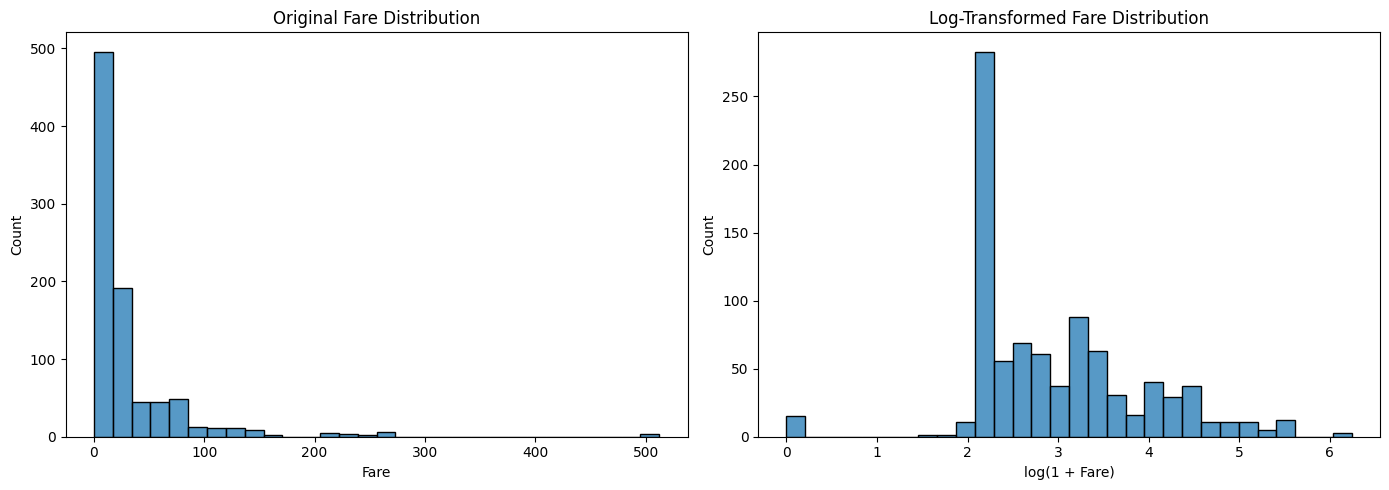

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean['fare'], bins=30, ax=axes[0])
axes[0].set_title('Original Fare Distribution')
axes[0].set_xlabel('Fare')

sns.histplot(np.log1p(df_clean['fare']), bins=30, ax=axes[1])
axes[1].set_title('Log-Transformed Fare Distribution')
axes[1].set_xlabel('log(1 + Fare)')

plt.tight_layout()
plt.show()

### Interpretation

The original fare distribution is highly right-skewed, with many low fares and a few extremely high values.  
After applying the log transformation, the distribution becomes less skewed and easier to interpret because the extreme values no longer dominate the chart.  
The transformed plot is more informative because it makes the structure of the majority of observations clearer.

In [18]:
# (b) Identify extreme fare outliers > 300
fare_outliers = df_clean[df_clean['fare'] > 300]
print("Number of fare outliers above 300:", len(fare_outliers))
display(fare_outliers[['survived', 'pclass', 'sex', 'fare', 'embarked', 'class']])

Number of fare outliers above 300: 3


,survived,pclass,sex,fare,embarked,class
258,1,1,female,512.3292,C,First
679,1,1,male,512.3292,C,First
737,1,1,male,512.3292,C,First


### Interpretation

These outliers appear to be legitimate premium fares rather than obvious data errors.  
They are likely associated with first-class passengers, special cabin arrangements, or large family/group bookings. Their presence is realistic given the class-based fare structure on the Titanic.

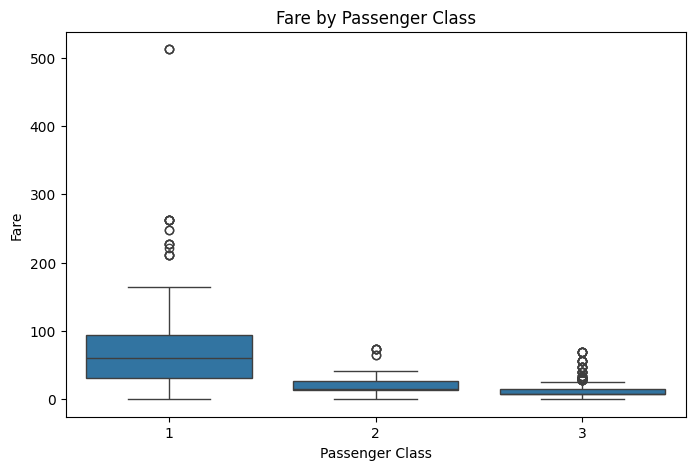

In [19]:
# (c) Box plot of fare by pclass
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='pclass', y='fare')
plt.title('Fare by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

### Interpretation

First class has the greatest spread in fare values and also contains the most extreme outliers.  
Third class fares are much lower and more compressed.  
This suggests that ticket pricing was strongly stratified by class, with first class offering a wider range of premium fare options.

## Q5 — Categorical Distributions

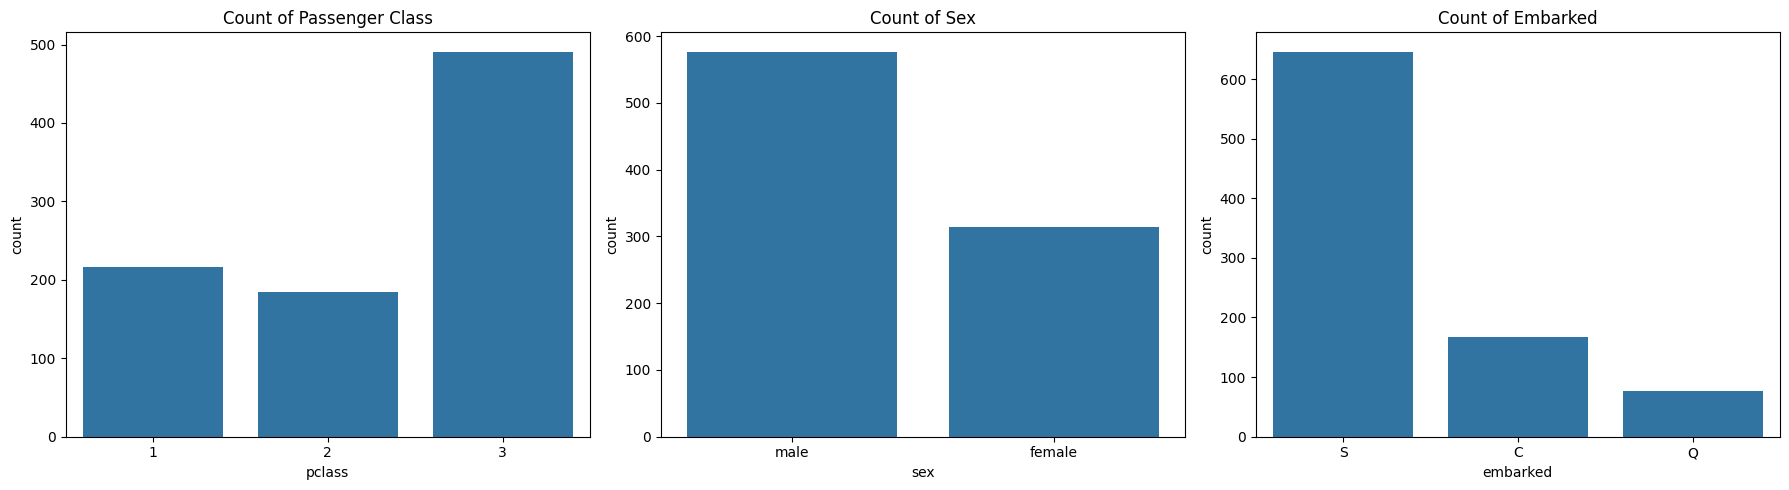

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df_clean, x='pclass', ax=axes[0])
axes[0].set_title('Count of Passenger Class')

sns.countplot(data=df_clean, x='sex', ax=axes[1])
axes[1].set_title('Count of Sex')

sns.countplot(data=df_clean, x='embarked', ax=axes[2])
axes[2].set_title('Count of Embarked')

plt.tight_layout()
plt.show()

### One Observation Per Chart

- **pclass:** Third-class passengers make up the largest group in the dataset.
- **sex:** Male passengers are more numerous than female passengers.
- **embarked:** Most passengers boarded from Southampton (`S`), making it the dominant embarkation point.

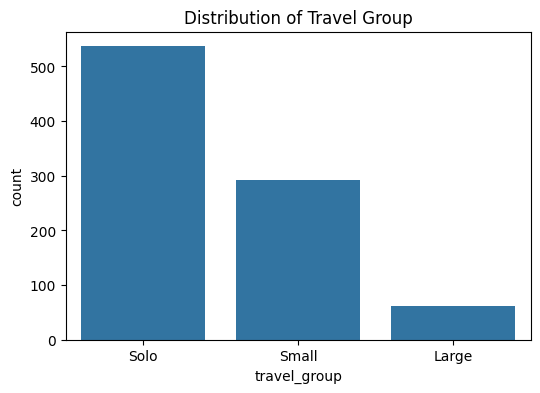

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='travel_group', order=['Solo', 'Small', 'Large'])
plt.title('Distribution of Travel Group')
plt.show()

### Interpretation

Travelling solo is the norm rather than the exception, since the `Solo` category appears most frequent.

In [ ]:
age_order = ['Child', 'Teen', 'Adult', 'Senior']
age_counts = df_clean['age_group'].value_counts().reindex(age_order)

plt.figure(figsize=(6, 4))
sns.barplot(x=age_counts.index, y=age_counts.values)
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

### Interpretation

Adults are by far the most represented age group in the dataset, while seniors and teens are the least represented.  
This indicates that the passenger population was dominated by working-age adults.

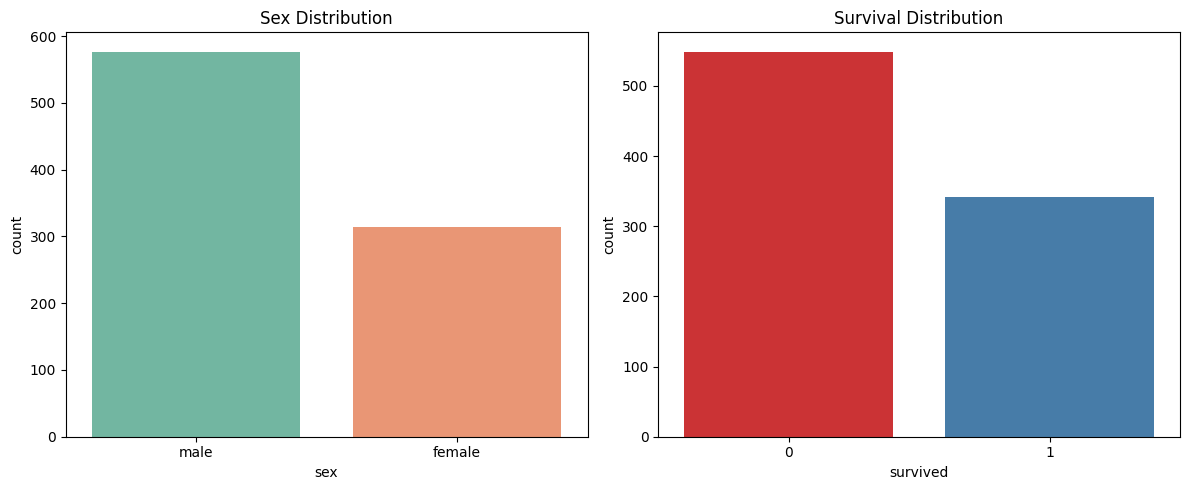

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df_clean, x='sex', ax=axes[0], palette='Set2')
axes[0].set_title('Sex Distribution')

sns.countplot(data=df_clean, x='survived', ax=axes[1], palette='Set1')
axes[1].set_title('Survival Distribution')

plt.tight_layout()
plt.show()

### Interpretation

Count plots alone are not enough to compare survival chances because they show totals, not proportions.  
A group may have more survivors in count simply because it has more people overall. Survival rate charts are more appropriate for comparing chances across groups.

# Part 3 — Bivariate & Multivariate Analysis
This part examines relationships between variables and helps identify patterns linked to survival.

## Q6 — Survival by Group

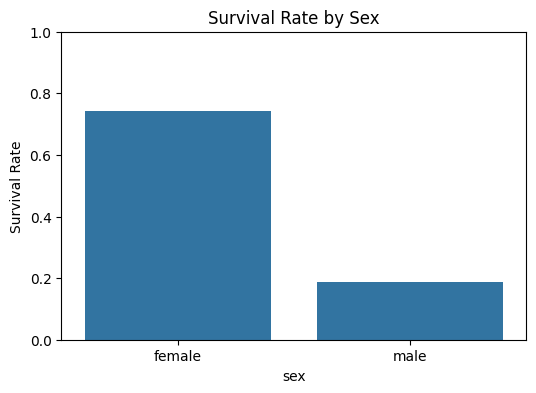

In [23]:
survival_by_sex = df_clean.groupby('sex')['survived'].mean().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(data=survival_by_sex, x='sex', y='survived')
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

### Interpretation

Females have a much higher survival rate than males.  
This result is expected because emergency evacuation on the Titanic generally prioritized women and children.

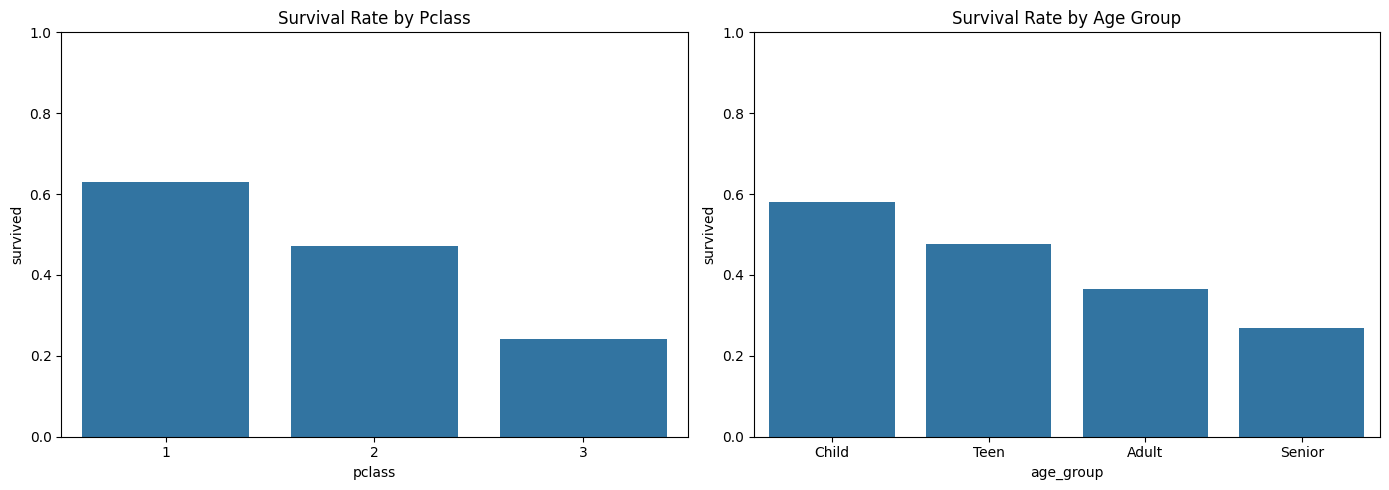

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_clean, x='pclass', y='survived', errorbar=None, ax=axes[0])
axes[0].set_title('Survival Rate by Pclass')
axes[0].set_ylim(0, 1)

sns.barplot(data=df_clean, x='age_group', y='survived',
            order=['Child', 'Teen', 'Adult', 'Senior'],
            errorbar=None, ax=axes[1])
axes[1].set_title('Survival Rate by Age Group')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

### Interpretation

**By pclass:** Survival decreases as passenger class decreases. First-class passengers had the highest survival rate, while third-class passengers had the lowest.  
**By age group:** Children show relatively higher survival, while adults, especially adult men, appear less likely to survive. This again supports the idea of evacuation priority.

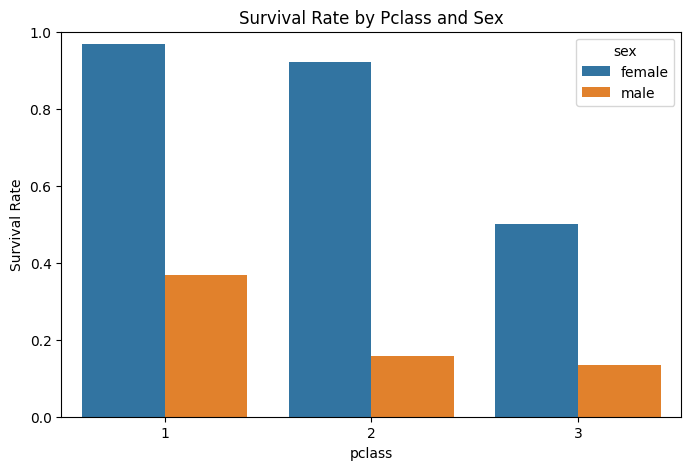

In [25]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_clean, x='pclass', y='survived', hue='sex', errorbar=None)
plt.title('Survival Rate by Pclass and Sex')
plt.ylim(0, 1)
plt.ylabel('Survival Rate')
plt.show()

### Interpretation

The “women and children first” pattern appears in all classes, but it is strongest in the upper classes.  
Females in first and second class had especially high survival rates, while third-class males had the lowest rates overall.

### Hypothesis Before Plotting

I expect passengers travelling in small groups to have slightly better survival rates than those travelling alone or in very large groups, because they may have had some social support without the coordination problems of large families.

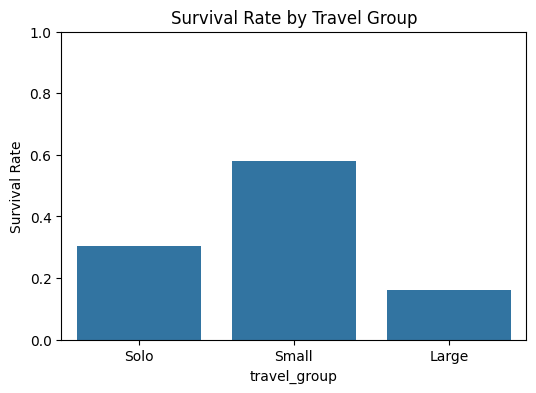

In [27]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df_clean, x='travel_group', y='survived', order=['Solo', 'Small', 'Large'], errorbar=None)
plt.title('Survival Rate by Travel Group')
plt.ylim(0, 1)
plt.ylabel('Survival Rate')
plt.show()

### Conclusion

The plot suggests that survival varies by travel group size.  
Small groups appear to do reasonably well, while solo travelers and large groups may face disadvantages. Large groups may have had more difficulty coordinating during evacuation.

## Q7 — Correlation & Heatmap

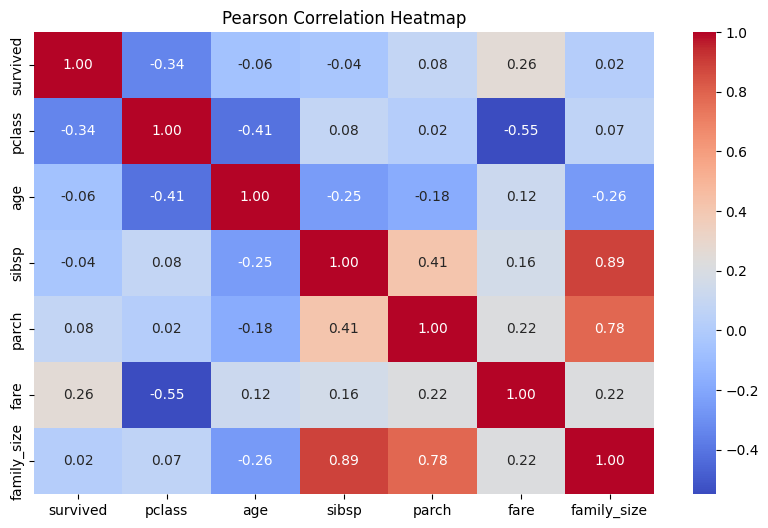

In [28]:
numeric_df = df_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation Heatmap')
plt.show()

In [29]:
# strongest correlations excluding diagonal
corr_pairs = (
    corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['var1', 'var2', 'correlation']
corr_pairs['abs_corr'] = corr_pairs['correlation'].abs()
corr_pairs['pair'] = corr_pairs.apply(lambda x: tuple(sorted([x['var1'], x['var2']])), axis=1)
corr_pairs = corr_pairs.drop_duplicates('pair').sort_values('abs_corr', ascending=False)

display(corr_pairs.head(10))

,var1,var2,correlation,abs_corr,pair
23,sibsp,family_size,0.890712,0.890712,"(family_size, sibsp)"
29,parch,family_size,0.783111,0.783111,"(family_size, parch)"
10,pclass,fare,-0.549500,0.549500,"(fare, pclass)"
21,sibsp,parch,0.414838,0.414838,"(parch, sibsp)"
7,pclass,age,-0.413583,0.413583,"(age, pclass)"
0,survived,pclass,-0.338481,0.338481,"(pclass, survived)"
17,age,family_size,-0.258456,0.258456,"(age, family_size)"
4,survived,fare,0.257307,0.257307,"(fare, survived)"
14,age,sibsp,-0.249854,0.249854,"(age, sibsp)"
35,fare,family_size,0.217138,0.217138,"(family_size, fare)"


### Top Correlations Interpretation

One strong negative correlation is likely between `pclass` and `fare`, since higher class passengers paid higher fares.  
Another strong relationship appears between `family_size` and the related count variables `sibsp` and `parch`, which is expected because `family_size` is derived from them.  
A meaningful correlation involving `survived` may appear with `fare` or `pclass`, showing that wealth and class were related to survival chances.

### Weak Correlation Discussion

A weak correlation between `age` and `fare` would not be surprising because age alone does not directly determine ticket price.  
Passengers of many different ages could travel in different classes, so the linear relationship between age and fare is weak.

### Limitation of Pearson Correlation

Pearson correlation measures only linear relationships.  
If two variables have a strong non-linear relationship, Pearson correlation may fail to capture it properly.

## Q8 — Scatter Plots & Pair Plots

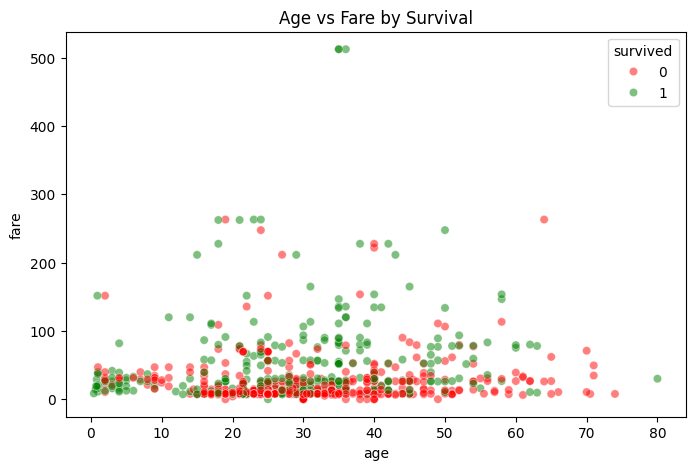

In [30]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_clean,
    x='age',
    y='fare',
    hue='survived',
    palette={0: 'red', 1: 'green'},
    alpha=0.5
)
plt.title('Age vs Fare by Survival')
plt.show()

### Interpretation

The plot shows a concentration of passengers at lower fares across many ages, especially among non-survivors.  
Survivors appear more visible in the higher-fare region, which suggests that expensive tickets and upper-class status may be linked to better survival.  
There is no single clean separation, but the upper-fare region contains relatively more survivors.

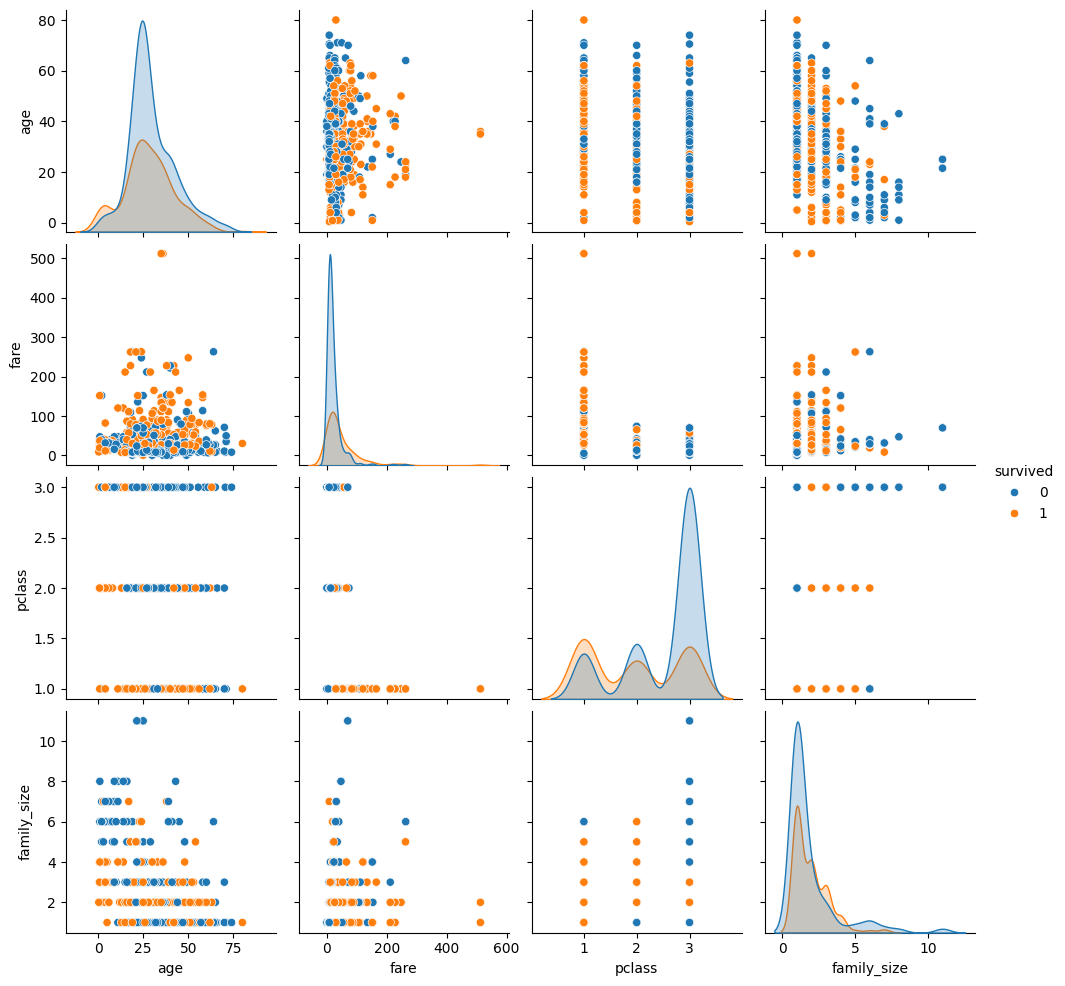

In [31]:
pair_df = df_clean[['age', 'fare', 'pclass', 'survived', 'family_size']].dropna()
sns.pairplot(pair_df, hue='survived')
plt.show()

### Interpretation

One of the most informative panels is the relationship between `fare` and `pclass`, because it clearly shows class-based separation.  
The plots involving `survived` also show that passengers with higher fares and lower class numbers were more likely to survive.

## Q9 — Violin & Swarm Plots

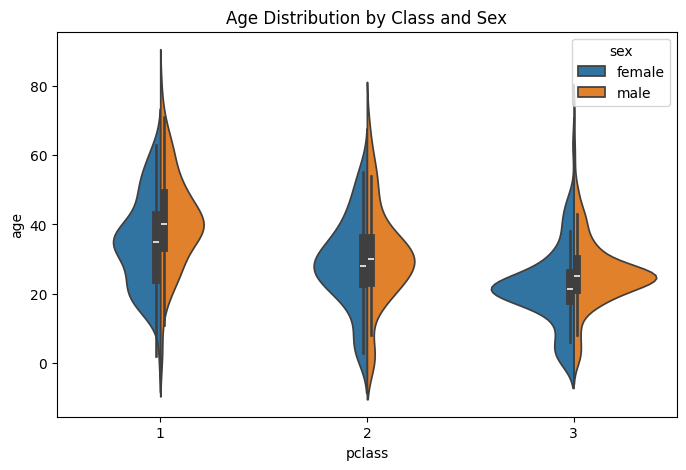

In [32]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_clean, x='pclass', y='age', hue='sex', split=True)
plt.title('Age Distribution by Class and Sex')
plt.show()

### Interpretation

The violin plot shows that age distributions differ across both sex and class.  
First-class passengers appear to include a broader range of adult ages, while third-class groups appear denser among younger and working-age adults.  
Some groups have wider spread, indicating more age diversity, while others are more concentrated around specific age ranges.  
Overall, class and sex together shape the age distribution in meaningful ways.

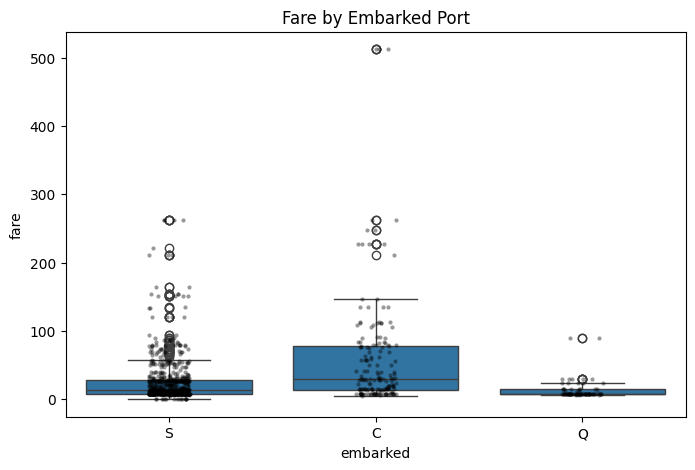

In [33]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='embarked', y='fare')
sns.stripplot(data=df_clean, x='embarked', y='fare', color='black', alpha=0.4, size=3)
plt.title('Fare by Embarked Port')
plt.show()

### Interpretation

The box plot summarizes fare spread and central tendency, while the strip plot shows the actual individual data points.  
Combining them is more informative because the box plot alone can hide the density and overlap of observations.  
The strip plot makes outliers and clustering much more visible.

## Q10 — Facet Grids

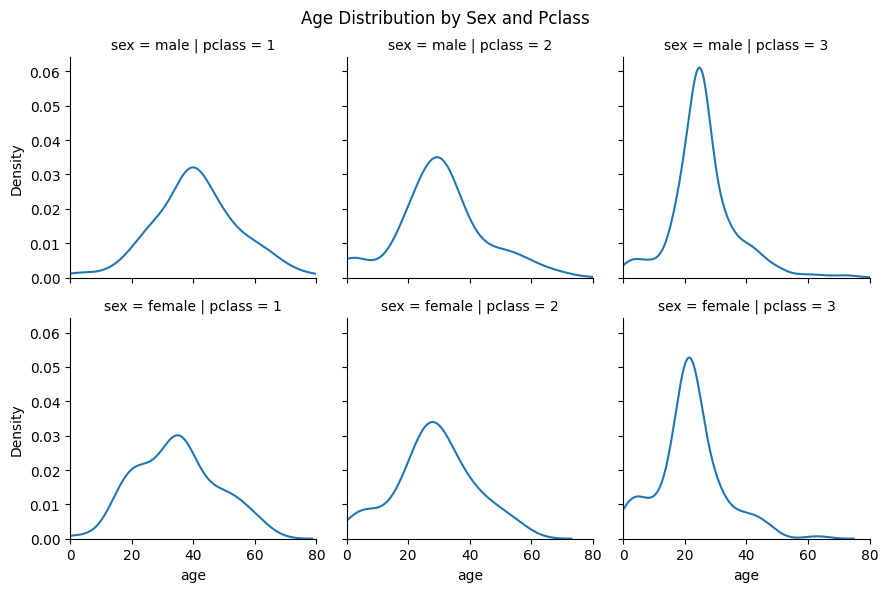

In [34]:
g = sns.FacetGrid(df_clean, row='sex', col='pclass', height=3)
g.map(sns.kdeplot, 'age')
g.set(xlim=(0, 80))
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Age Distribution by Sex and Pclass')
plt.show()

### Interpretation

The grid shows that age distributions vary across both sex and class.  
Upper-class passengers include broader adult age ranges, while third-class groups seem more concentrated.  
The faceted layout makes it easier to compare subgroups directly without mixing them into one crowded chart.

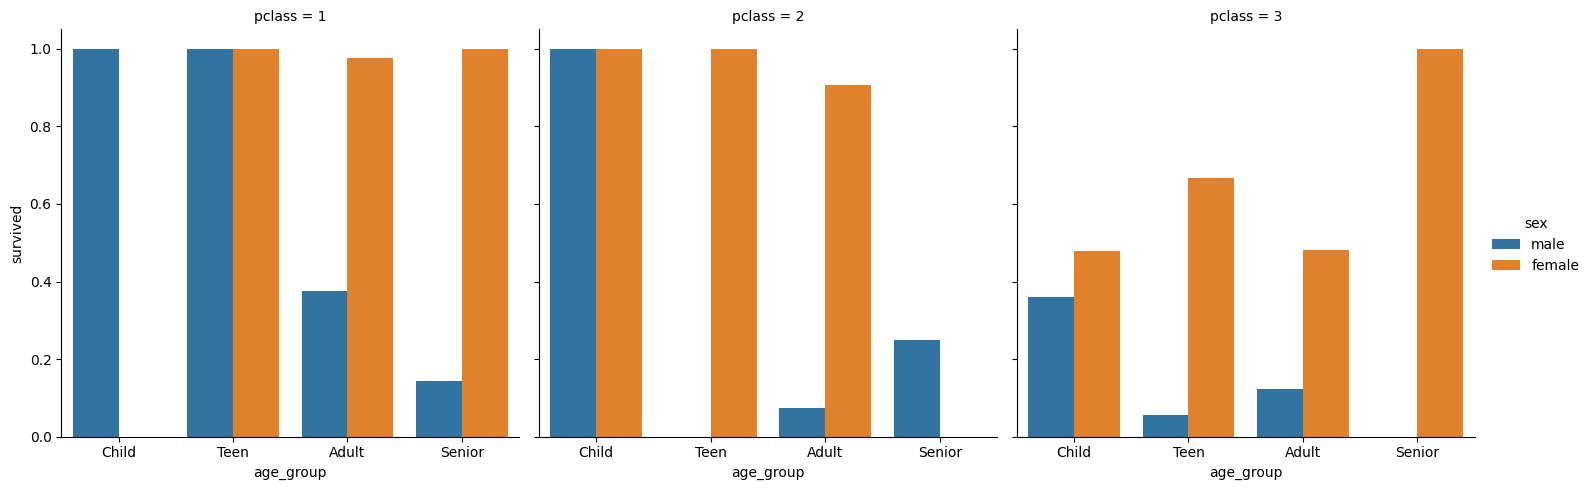

In [35]:
sns.catplot(
    data=df_clean,
    x='age_group',
    y='survived',
    col='pclass',
    hue='sex',
    kind='bar',
    order=['Child', 'Teen', 'Adult', 'Senior'],
    errorbar=None
)
plt.show()

### Interpretation

A surprisingly low-survival combination is likely adult males in third class.  
A high-survival combination is likely females in first class.  
This reinforces the idea that survival depended jointly on class, sex, and age rather than any one variable alone.

## Q11 — Annotated Narrative Chart
This figure combines multiple variables into one storytelling visualization.

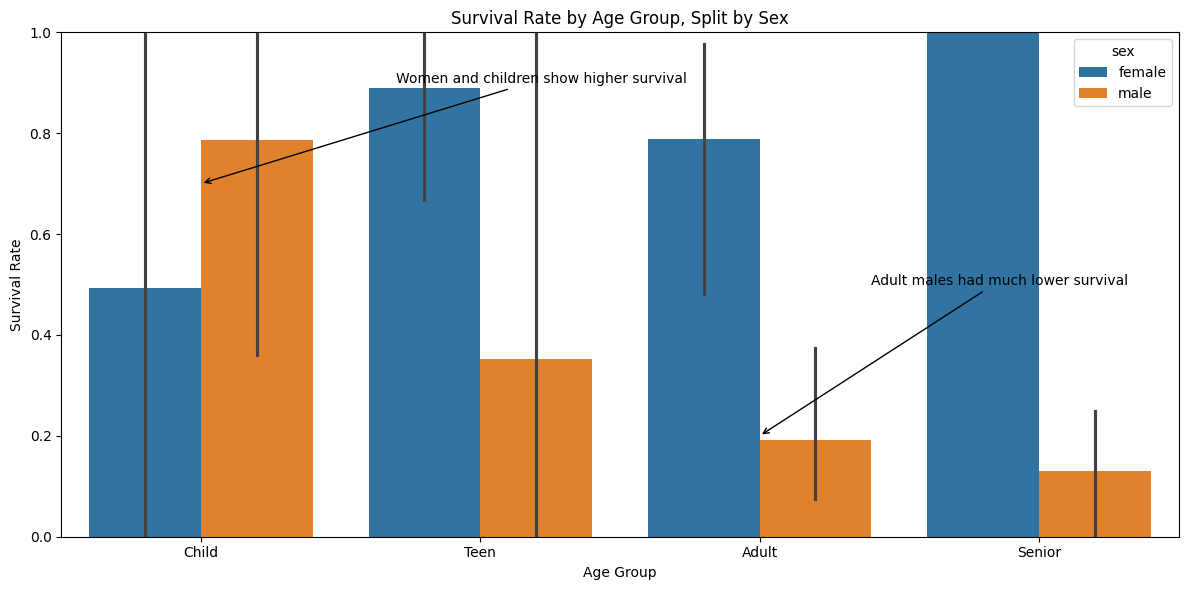

In [36]:
plot_df = df_clean.groupby(['pclass', 'sex', 'age_group'])['survived'].mean().reset_index()

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=plot_df,
    x='age_group',
    y='survived',
    hue='sex'
)

plt.title('Survival Rate by Age Group, Split by Sex')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)

plt.annotate(
    'Women and children show higher survival',
    xy=(0, 0.7),
    xytext=(0.7, 0.9),
    arrowprops=dict(arrowstyle='->'),
    fontsize=10
)

plt.annotate(
    'Adult males had much lower survival',
    xy=(2, 0.2),
    xytext=(2.4, 0.5),
    arrowprops=dict(arrowstyle='->'),
    fontsize=10
)

plt.tight_layout()
plt.show()

### Narrative Caption

This chart highlights how survival on the Titanic depended strongly on demographic group.  
Women and children consistently show higher survival rates than adult men.  
The pattern aligns with historical accounts of evacuation priority being given to women and children.  
Adult males appear to have the lowest survival rates, especially in lower classes.  
The chart tells a clear story: survival was not random, but shaped by social norms and class structure.  
This makes the figure useful not only as a chart, but also as a narrative summary of the disaster.